In [1]:
# 05_shap_xai
#
# 목적: 최종 LightGBM Enhanced v2 모델에 SHAP을 적용해
#      (1) 전체적으로 어떤 피처가 이탈 예측에 중요한지, (2) 개별 고객 단위로 왜 이탈 위험이
#      높다고 예측했는지를 설명한다.
#
# 주의: SHAP은 "모델이 무엇을 근거로 그렇게 예측했는가"를 보여주는 것이지, 실제 이탈의
#      진짜 원인(인과관계)을 증명하는 것이 아니다. 상관관계 기반 설명으로 이해해야 한다.
#
# 입력: data/processed/model_table_enhanced_v2.csv, models/lightgbm_enhanced_v2.txt,
#      models/lightgbm_enhanced_v2_meta.json
# 출력: data/processed/shap_sample_v2.pkl, data/dashboard/shap_importance.csv

In [2]:
import json
import pickle
import time
import numpy as np
import pandas as pd
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROCESSED_DIR = Path("../data/processed")
MODELS_DIR = Path("../models")
DASH_DATA = Path("../data/dashboard")
DASH_DATA.mkdir(parents=True, exist_ok=True)

sns.set_style("whitegrid", {"grid.color": "#e1e0d9", "axes.edgecolor": "#c3c2b7"})
plt.rcParams.update({
    "figure.dpi": 110,
    "font.family": "Malgun Gothic",
    "axes.unicode_minus": False,
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "axes.titlecolor": "#0b0b0b",
    "xtick.color": "#898781",
    "ytick.color": "#898781",
    "grid.color": "#e1e0d9",
    "text.color": "#0b0b0b",
})
SERIES_1 = "#2a78d6"

DROP_COLS = ["msno", "snapshot", "split", "is_churn"]
# 50,000행으로는 TreeExplainer가 900초 타임아웃을 넘겨서 5,000행으로 축소
# 전체 Test 대신 대표 샘플을 사용해 계산 시간과 메모리를 제한한다.
SAMPLE_SIZE = 5_000
RANDOM_STATE = 42

In [3]:
with open(MODELS_DIR / "lightgbm_enhanced_v2_meta.json", encoding="utf-8") as f:
    model_meta = json.load(f)

FEATURE_COLS = model_meta["feature_cols"]
CATEGORICAL_COLS = model_meta["categorical_cols"]

df = pd.read_csv(PROCESSED_DIR / "model_table_enhanced_v2.csv", low_memory=False)
assert df.shape == (992931, 61)
assert len(FEATURE_COLS) == 57
assert df["snapshot"].eq("2017-01-31").all()
for column in CATEGORICAL_COLS:
    df[column] = df[column].astype("category")

test_df = df[df["split"] == "test"]
sample_df = test_df.sample(n=min(SAMPLE_SIZE, len(test_df)), random_state=RANDOM_STATE).reset_index(drop=True)
X_sample = sample_df[FEATURE_COLS]

model = lgb.Booster(model_file=str(MODELS_DIR / "lightgbm_enhanced_v2.txt"))
assert model.num_feature() == len(FEATURE_COLS)
print(f"SHAP 계산 대상: Test {len(test_df):,}명 중 샘플 {len(X_sample):,}명")
print(f"최종 v2 피처 수: {len(FEATURE_COLS)}")

SHAP 계산 대상: Test 148,940명 중 샘플 5,000명
최종 v2 피처 수: 57


In [4]:
t0 = time.time()
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)
print(f"SHAP 계산 소요 시간: {time.time() - t0:.1f}s")

# LightGBM 이진분류의 shap_values는 (n, features) 형태로 나오거나 [class0, class1] 리스트로 나올 수 있음
if isinstance(shap_values, list):
    shap_values = shap_values[1]

print(f"shap_values shape: {shap_values.shape}")

SHAP 계산 소요 시간: 65.2s
shap_values shape: (5000, 57)


c:\Users\MoonSungHo\skn34-st\team_project\SKN34-2nd-2Team\My_venv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


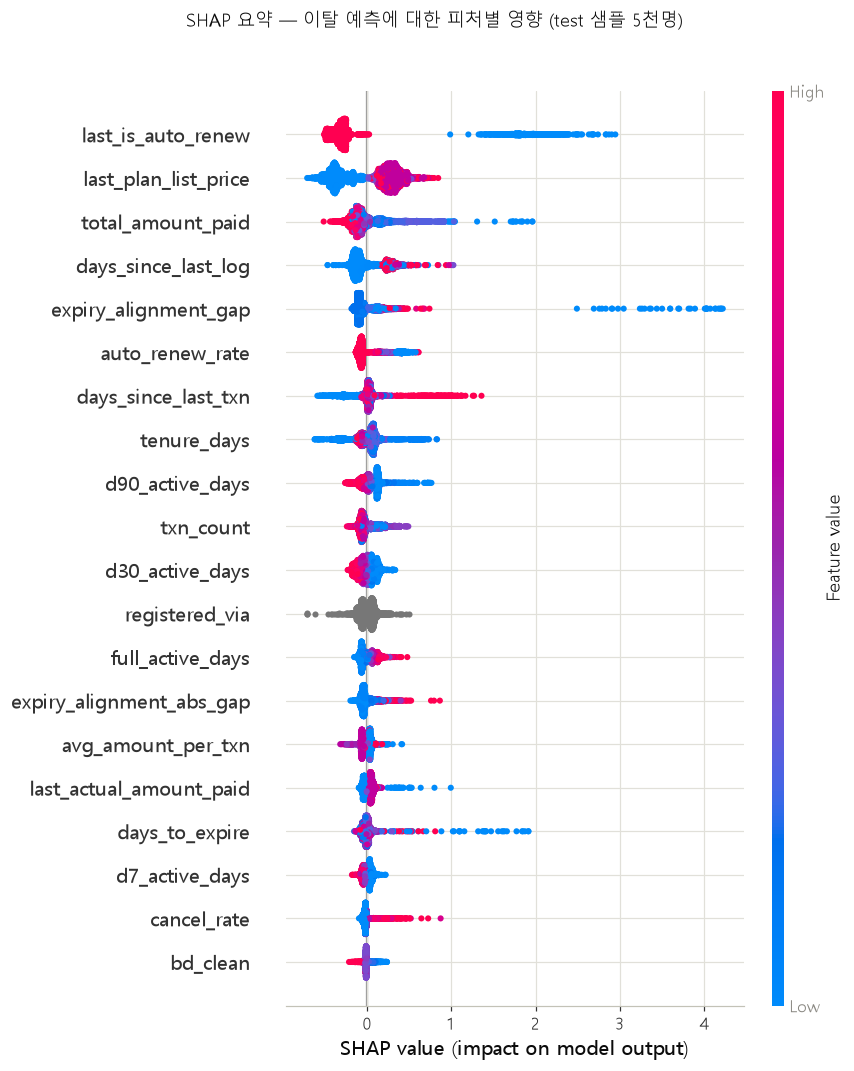

In [5]:
shap.summary_plot(shap_values, X_sample, show=False, max_display=20)
fig = plt.gcf()
fig.suptitle("SHAP 요약 — 이탈 예측에 대한 피처별 영향 (test 샘플 5천명)", y=1.02)
plt.tight_layout()
plt.show()

In [6]:
mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=FEATURE_COLS).sort_values(ascending=False)
top_features = mean_abs_shap.head(4).index.tolist()
print("SHAP 기준 상위 피처:")
print(mean_abs_shap.head(10))

shap_importance = mean_abs_shap.rename("mean_abs_shap").reset_index()
shap_importance.columns = ["feature", "mean_abs_shap"]
shap_importance.to_csv(DASH_DATA / "shap_importance.csv", index=False)
print(f"DB 적재용 저장: {DASH_DATA / 'shap_importance.csv'}")

SHAP 기준 상위 피처:
last_is_auto_renew      0.523108
last_plan_list_price    0.314294
total_amount_paid       0.159465
days_since_last_log     0.157507
expiry_alignment_gap    0.130595
auto_renew_rate         0.123037
days_since_last_txn     0.102252
tenure_days             0.101451
d90_active_days         0.080374
txn_count               0.078532
dtype: float64
DB 적재용 저장: ..\data\dashboard\shap_importance.csv


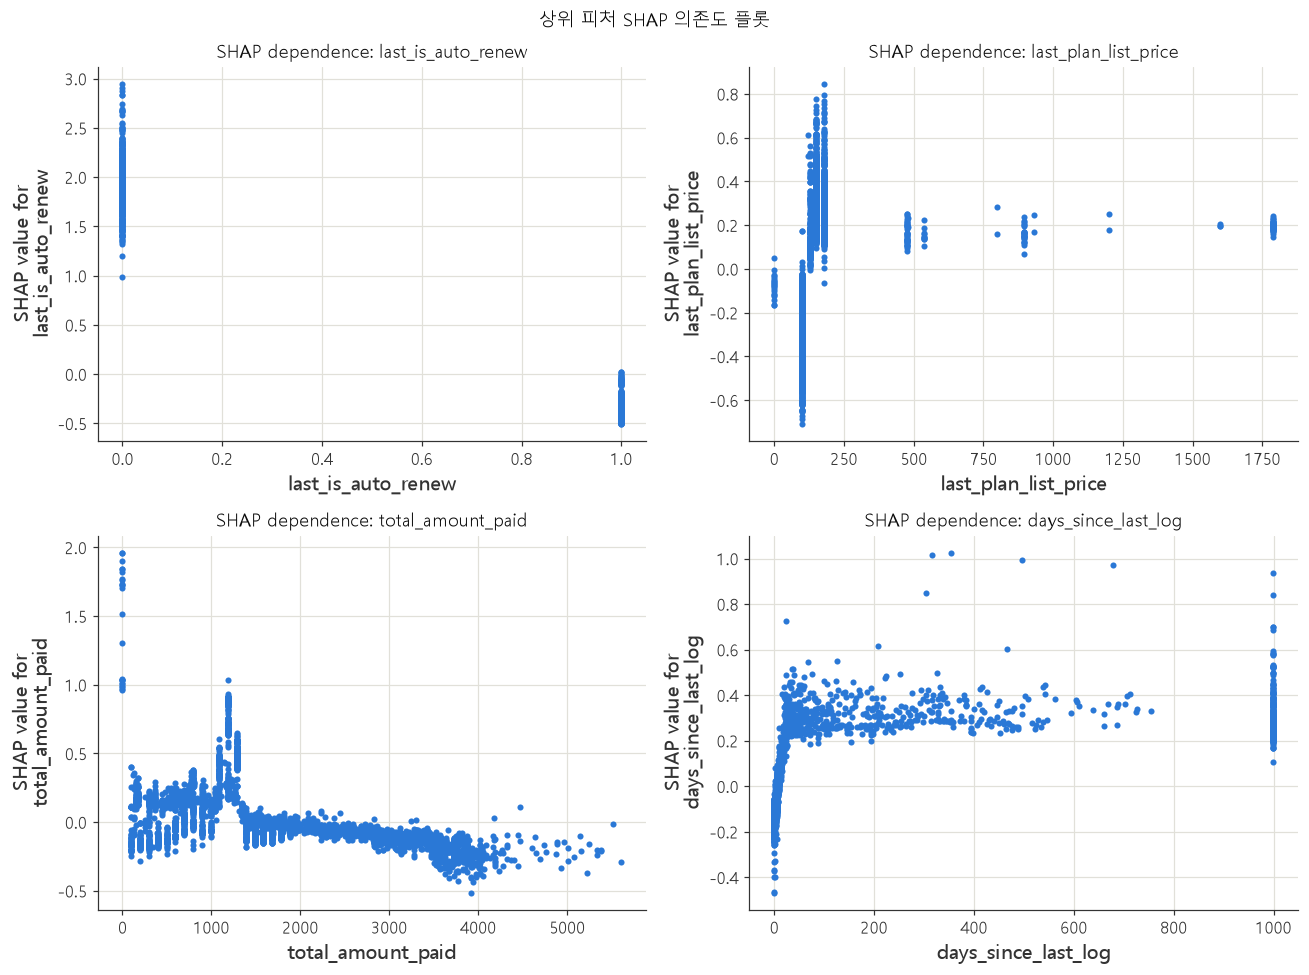

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, feat in zip(axes.flat, top_features):
    shap.dependence_plot(feat, shap_values, X_sample, ax=ax, show=False, interaction_index=None, color=SERIES_1)
    ax.set_title(f"SHAP dependence: {feat}")
fig.suptitle("상위 피처 SHAP 의존도 플롯")
plt.tight_layout()
plt.show()

In [8]:
# 개별 고객 설명 예시: 샘플 중 예측 이탈확률이 가장 높은 고객 1명
pred_proba = model.predict(X_sample)
top_risk_idx = int(np.argmax(pred_proba))

print(f"예시 고객 msno: {sample_df.loc[top_risk_idx, 'msno']}")
print(f"예측 이탈확률: {pred_proba[top_risk_idx]:.4f}")

customer_shap = pd.Series(shap_values[top_risk_idx], index=FEATURE_COLS).sort_values(key=abs, ascending=False)
print("\n이 고객의 이탈확률에 가장 크게 기여한 피처 top 10 (SHAP value):")
print(customer_shap.head(10))

예시 고객 msno: 4LHoCrSuTSzYqZg8O25ZX+ZbHieiqe6/ro68KCRQVxs=
예측 이탈확률: 0.9973

이 고객의 이탈확률에 가장 크게 기여한 피처 top 10 (SHAP value):
last_is_auto_renew         2.079940
days_to_expire             1.102013
days_since_last_log        1.017460
days_since_last_txn        0.995705
d90_active_days            0.719102
auto_renew_change          0.630128
auto_renew_rate            0.608350
remaining_plan_ratio       0.416989
last_actual_amount_paid    0.331919
d30_active_days            0.315936
dtype: float64


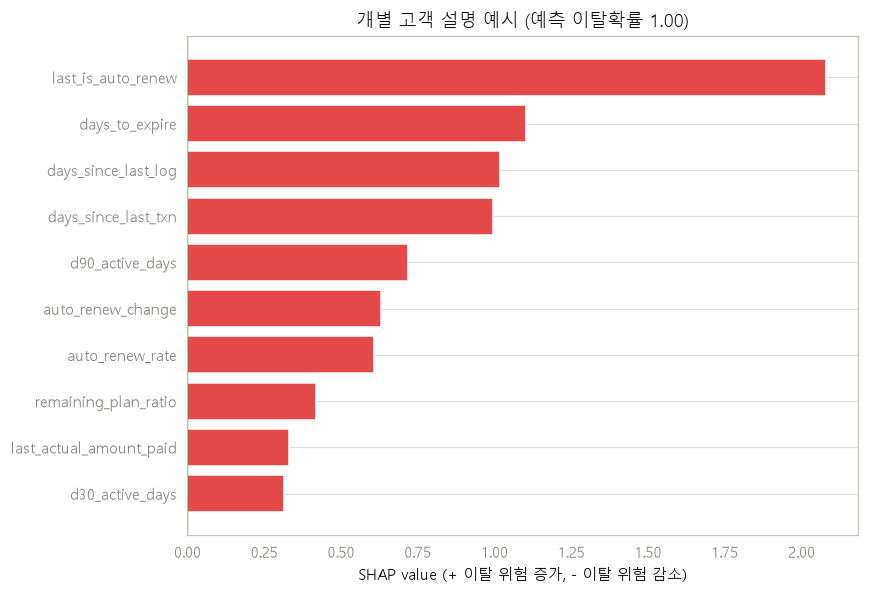

In [9]:
top10 = customer_shap.head(10).sort_values()
colors = ["#e34948" if v > 0 else "#2a78d6" for v in top10.values]

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(top10.index, top10.values, color=colors)
ax.axvline(0, color="#0b0b0b", linewidth=0.8)
ax.set_xlabel("SHAP value (+ 이탈 위험 증가, - 이탈 위험 감소)")
ax.set_title(f"개별 고객 설명 예시 (예측 이탈확률 {pred_proba[top_risk_idx]:.2f})")
ax.grid(axis="x")
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

In [10]:
with open(PROCESSED_DIR / "shap_sample_v2.pkl", "wb") as f:
    pickle.dump({
        "msno": sample_df["msno"].values,
        "feature_cols": FEATURE_COLS,
        "X_sample": X_sample,
        "shap_values": shap_values,
        "pred_proba": pred_proba,
    }, f)
print(f"저장 완료: {PROCESSED_DIR / 'shap_sample_v2.pkl'} (06단계 세그멘테이션에서 재사용)")

저장 완료: ..\data\processed\shap_sample_v2.pkl (06단계 세그멘테이션에서 재사용)


In [11]:
# ------------------------------------------------------------------
# 해석 시 주의할 점
# 1. SHAP은 "모델이 이 예측을 할 때 각 피처를 얼마나/어느 방향으로 반영했는가"를 보여주는 것이지,
#    실제 유저의 이탈 원인을 인과적으로 증명하는 것이 아니다.
# 2. test split 5천 명 샘플 기준 분석이며, 전체 모집단과 분포가 다를 수 있다.
# ------------------------------------------------------------------
print("SHAP 분석 완료 (위 주석의 해석 주의사항 참고)")

SHAP 분석 완료 (위 주석의 해석 주의사항 참고)
